<a id="top"></a>
# Exploratory Data Analysis V1: Hypertension Risk Atlas
**ADS-599 Capstone Project · Group 2 · Nancy Walker & Michelle Wang**

---

## Overview

This notebook presents the exploratory data analysis (EDA) of the merged county-level
analytic dataset (`data/processed/master_dataset.csv`), which integrates four public
sources — CDC PLACES, USDA Food Access Research Atlas, U.S. Census ACS, and County
Health Rankings & Roadmaps — joined on the 5-digit FIPS county code.

**Purpose.** Profile the structure and quality of the merged table, characterize the
target variable (county-level hypertension prevalence), identify candidate predictors,
and flag data-quality issues (missingness, target leakage, join integrity) that inform
the cleaning and feature-engineering plan.

**Conventions.** Python code follows the
[PEP 8 style guide](https://peps.python.org/pep-0008/) (snake_case names,
imports grouped at the top, ≤ 79-character lines). Companion R scripts in `code/`
follow the [Tidyverse style guide](https://style.tidyverse.org/).

## Table of Contents
1. [Setup and Configuration](#setup)
2. [Data Loading and Key Validation](#loading)
3. [Structural Overview](#structure)
4. [Missingness Profile](#missingness)
5. [Target Variable Analysis](#target)
6. [Candidate Predictor Screen](#predictors)
7. [Data Integrity Checks](#integrity)
8. [Findings and Next Steps](#findings)

[Back to top](#top)

<a id="setup"></a>
## 1. Setup and Configuration


In [12]:
# Import libraries and define project constants; expected outcome: a
# configured environment where every later cell reads paths and column
# names from a single place (no magic strings scattered through code).
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Configuration -------------------------------------------------
DATA_PATH = os.environ.get(
    "DATA_PATH", "../data/processed/master_dataset.csv"
)
FIG_DIR = "figures"

FIPS_COL = "GEOID"          # 5-digit county FIPS key (edit if named
                            # differently in the merged table)
TARGET_COL = None           # detected automatically in Section 2

MISSING_DROP_THRESHOLD = 0.50   # drop candidates: > 50% missing
LEAKAGE_CORR_THRESHOLD = 0.95   # leakage flags: |r| > 0.95

os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_rows", 100)

print(f"Data path: {DATA_PATH}")

Data path: ../data/processed/master_dataset.csv


<a id="loading"></a>
## 2. Data Loading and Key Validation

The FIPS code must be read as a zero-padded string: numeric parsing silently
turns `"06001"` (Alameda County, CA) into `6001`, which breaks every
downstream join. The target variable (hypertension prevalence, sourced from
CDC PLACES) is detected by name pattern and confirmed explicitly.

[Back to top](#top)

In [13]:
# Load the merged analytic table with FIPS as string; expected outcome:
# a DataFrame of ~3,222 rows (counties) x ~872 columns with a valid
# 5-character county key.
df = pd.read_csv(DATA_PATH, low_memory=False)

if FIPS_COL not in df.columns:
    fips_like = [
        col for col in df.columns
        if col.lower() in ("geoid", "fips", "fips_code", "county_fips")
    ]
    if not fips_like:
        raise KeyError(
            f"No FIPS column found; first columns: {list(df.columns[:20])}"
        )
    FIPS_COL = fips_like[0]

df[FIPS_COL] = (
    df[FIPS_COL]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

print(f"FIPS key column: {FIPS_COL}")
print(f"Table shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

FIPS key column: GEOID
Table shape: 3,222 rows x 872 columns


In [14]:
# Detect the hypertension-prevalence target column; expected outcome:
# TARGET_COL set to one confirmed column name. In this merged table CDC
# PLACES measures are spelled out (e.g., "High blood pressure among
# adults") rather than coded as 'BPHIGH'; the medication-adherence
# measure is excluded here since it is a target-leakage risk, not the
# target itself.
target_candidates = [
    col for col in df.columns
    if ("hypertension" in col.lower() or "high blood pressure" in col.lower())
    and "medicine" not in col.lower()
]
print("Target candidates found:")
for col in target_candidates:
    print(f"  - {col}")

# If several candidates appear, set TARGET_COL manually to the agreed
# prevalence measure (e.g., crude prevalence, not the CI bounds).
TARGET_COL = target_candidates[0]
print(f"\nUsing TARGET_COL = '{TARGET_COL}'")

Target candidates found:
  - High blood pressure among adults

Using TARGET_COL = 'High blood pressure among adults'


<a id="structure"></a>
## 3. Structural Overview

With 800+ columns, the overview stays aggregate: data-type counts and a
scan of non-numeric columns (typically identifiers, names, or free text
that will not enter the model matrix).

[Back to top](#top)

In [15]:
# Summarize column data types; expected outcome: a count of columns per
# dtype and a short list of non-numeric columns to review for exclusion.
print(df.dtypes.value_counts())

non_numeric_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"\n{len(non_numeric_cols)} non-numeric columns (first 20):")
print(non_numeric_cols[:20])

float64    868
object       3
int64        1
Name: count, dtype: int64

3 non-numeric columns (first 20):
['GEOID', 'state', 'county']


In [16]:
# Preview the first rows; expected outcome: visual confirmation that the
# join produced one row per county with plausible values.
df.head()

,GEOID,poverty_rate,med_income,All teeth lost among adults aged >=65 years,Any disability among adults,Arthritis among adults,Binge drinking among adults,Cancer (non-skin) or melanoma among adults,Cholesterol screening among adults,Chronic obstructive pulmonary disease among adults,...,v058_rawvalue,v058_numerator,v058_denominator,v058_cilow,v058_cihigh,v051_rawvalue,v051_numerator,v051_denominator,v051_cilow,v051_cihigh
0,01001,6275,69841.0,14.223529,34.394118,29.929412,14.517647,8.076471,86.300000,7.658824,...,0.406768,23920.0,58805.0,NaN,NaN,60342.0,NaN,NaN,NaN,NaN
1,01003,24819,75019.0,12.079070,34.216279,33.427907,14.502326,10.455814,87.951163,7.790698,...,0.375865,87113.0,231767.0,NaN,NaN,253507.0,NaN,NaN,NaN,NaN
2,01005,4746,44290.0,23.911111,44.022222,35.333333,11.933333,8.088889,85.300000,11.122222,...,0.659200,16627.0,25223.0,NaN,NaN,24585.0,NaN,NaN,NaN,NaN
3,01007,4258,51215.0,21.837500,41.250000,32.037500,14.212500,8.037500,83.262500,10.250000,...,1.000000,22293.0,22293.0,NaN,NaN,21868.0,NaN,NaN,NaN,NaN
4,01009,8269,61096.0,16.625000,38.362500,31.893750,14.506250,9.162500,84.687500,9.387500,...,0.904894,53510.0,59134.0,NaN,NaN,59816.0,NaN,NaN,NaN,NaN


<a id="missingness"></a>
## 4. Missingness Profile

columns above the 50% threshold
become drop candidates; moderately missing columns require an imputation
decision. The full per-column table is exported for the cleaning-plan issue.

[Back to top](#top)

In [17]:
# Compute the fraction missing per column; expected outcome: counts of
# columns crossing 90/50/20% thresholds and the 20 worst columns.
missing_frac = df.isna().mean().sort_values(ascending=False)

for threshold in (0.90, 0.50, 0.20):
    n_over = int((missing_frac > threshold).sum())
    print(f"Columns > {threshold:.0%} missing: {n_over}")
print(f"Columns fully complete: {int((missing_frac == 0).sum())}")

missing_frac.head(20)

Columns > 90% missing: 275
Columns > 50% missing: 429
Columns > 20% missing: 498
Columns fully complete: 2


v051_cihigh         1.0
v083_cihigh         1.0
v045_cilow          1.0
v045_denominator    1.0
v143_denominator    1.0
v143_numerator      1.0
v139_cihigh         1.0
v042_numerator      1.0
v042_denominator    1.0
v139_cilow          1.0
v139_denominator    1.0
v002_numerator      1.0
v145_denominator    1.0
v002_denominator    1.0
v083_cilow          1.0
v183_denominator    1.0
v183_numerator      1.0
v155_numerator      1.0
v155_denominator    1.0
v155_cilow          1.0
dtype: float64

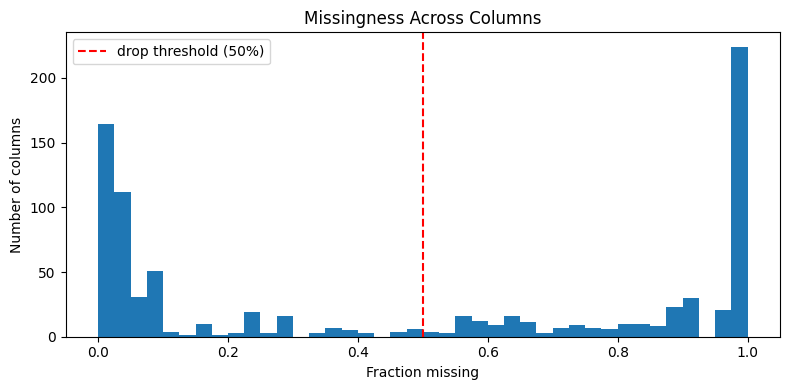

In [18]:
# Export the missingness table and plot its distribution; expected
# outcome: figures/missingness_by_column.csv (drop-list input) and a
# histogram showing how missingness concentrates across columns.
missing_frac.rename("missing_fraction").to_csv(
    f"{FIG_DIR}/missingness_by_column.csv"
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(missing_frac, bins=40)
ax.axvline(MISSING_DROP_THRESHOLD, color="red", linestyle="--",
           label=f"drop threshold ({MISSING_DROP_THRESHOLD:.0%})")
ax.set_xlabel("Fraction missing")
ax.set_ylabel("Number of columns")
ax.set_title("Missingness Across Columns")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/missingness_hist.png", dpi=150)
plt.show()

<a id="target"></a>
## 5. Target Variable Analysis

County-level hypertension prevalence is the supervised-regression target.
Its distribution shape informs whether a transformation is warranted and
provides the reference for the mean-prediction baseline used in evaluation.

[Back to top](#top)

count    2956.000000
mean       39.066073
std         5.485359
min        21.320455
25%        35.600000
50%        38.825705
75%        42.493750
max        59.400000
Name: High blood pressure among adults, dtype: float64

Counties missing target: 266


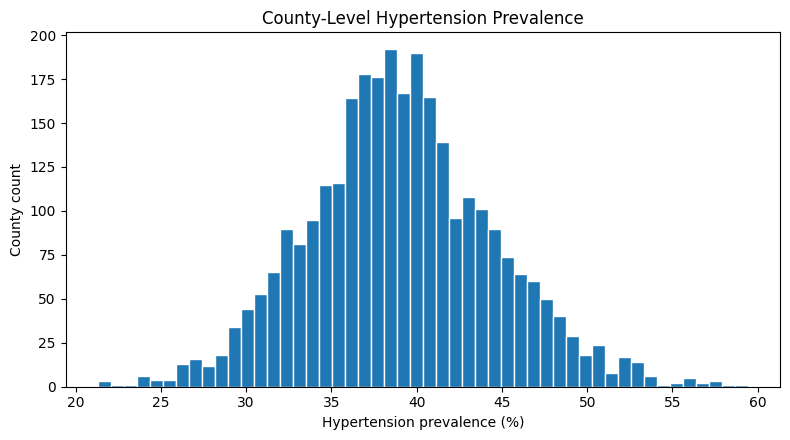

In [19]:
# Summarize and plot the target distribution; expected outcome: summary
# statistics, a missing-count check, and a saved histogram for the
# article's Data section.
print(df[TARGET_COL].describe())
print(f"\nCounties missing target: {int(df[TARGET_COL].isna().sum())}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df[TARGET_COL].dropna(), bins=50, edgecolor="white")
ax.set_xlabel("Hypertension prevalence (%)")
ax.set_ylabel("County count")
ax.set_title("County-Level Hypertension Prevalence")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/target_distribution.png", dpi=150)
plt.show()

<a id="predictors"></a>
## 6. Candidate Predictor Screen

A univariate Pearson-correlation screen against the target ranks candidate
predictors. This is descriptive, not causal; it seeds feature selection and
doubles as a first target-leakage check — any column correlating above
|r| = 0.95 (for example, medication-for-hypertension measures) is flagged
for exclusion, as committed in the proposal.

[Back to top](#top)

/Users/xuanwang/.pyenv/versions/3.13.7/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/xuanwang/.pyenv/versions/3.13.7/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


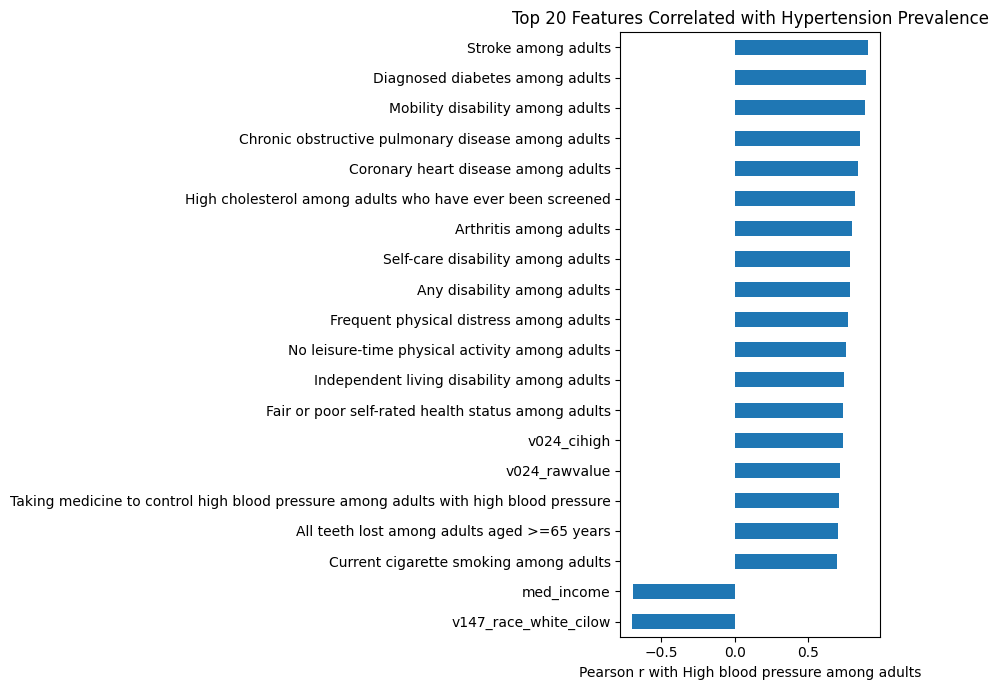

No leakage suspects above threshold.


In [20]:
# Rank numeric features by absolute correlation with the target;
# expected outcome: a top-20 bar chart of candidate predictors and an
# explicit list of leakage suspects.
numeric_df = df.select_dtypes("number")
corr_with_target = (
    numeric_df.corrwith(df[TARGET_COL])
    .drop(labels=[TARGET_COL], errors="ignore")
    .dropna()
)
top_20 = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
top_20.sort_values().plot.barh(ax=ax)
ax.set_xlabel(f"Pearson r with {TARGET_COL}")
ax.set_title("Top 20 Features Correlated with Hypertension Prevalence")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/top20_correlations.png", dpi=150)
plt.show()

leakage_suspects = top_20[top_20.abs() > LEAKAGE_CORR_THRESHOLD]
if not leakage_suspects.empty:
    print("Leakage suspects (|r| > 0.95) — review for exclusion:")
    print(leakage_suspects)
else:
    print("No leakage suspects above threshold.")

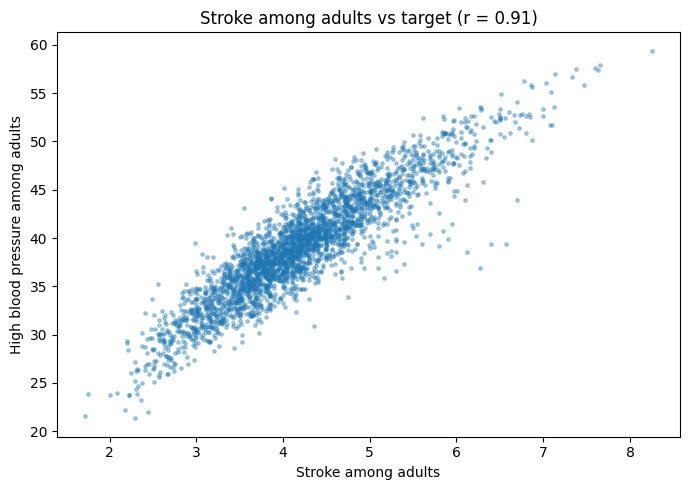

In [21]:
# Plot the strongest single predictor against the target; expected
# outcome: a scatter plot revealing whether the leading relationship
# looks linear or non-linear (motivates tree-based models).
best_feature = top_20.abs().idxmax()
best_r = corr_with_target[best_feature]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df[best_feature], df[TARGET_COL], s=6, alpha=0.35)
ax.set_xlabel(best_feature)
ax.set_ylabel(TARGET_COL)
ax.set_title(f"{best_feature} vs target (r = {best_r:.2f})")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/best_feature_scatter.png", dpi=150)
plt.show()

<a id="integrity"></a>
## 7. Data Integrity Checks

These assertions mirror the FIPS validation in the R ingestion pipeline
(`code/`): both languages must agree on the join key. A failure here means
an upstream join problem, not an EDA problem.

[Back to top](#top)

In [22]:
# Validate the county key and row count; expected outcome: zero
# duplicate FIPS codes, uniformly 5-character keys, and a row count
# consistent with the proposal (3,222 counties).
n_duplicates = int(df[FIPS_COL].duplicated().sum())
length_counts = df[FIPS_COL].str.len().value_counts().to_dict()
n_states = df[FIPS_COL].str[:2].nunique()

print(f"Duplicate FIPS keys : {n_duplicates}")
print(f"Key length counts   : {length_counts} (expect all 5)")
print(f"Distinct state codes: {n_states} (expect ~51-56)")
print(f"Row count           : {len(df):,} (proposal: 3,222)")

assert n_duplicates == 0, "Duplicate FIPS keys — upstream join issue."
assert set(length_counts) == {5}, "Non-5-character FIPS keys found."
print("\nAll integrity checks passed.")

Duplicate FIPS keys : 0
Key length counts   : {5: 3222} (expect all 5)
Distinct state codes: 52 (expect ~51-56)
Row count           : 3,222 (proposal: 3,222)

All integrity checks passed.


<a id="findings"></a>
## 8. Findings and Next Steps

*(Complete after execution — this section feeds the cleaning-plan issue and
the Data and Methods draft.)*

| Question | Finding |
|---|---|
| Table matches proposal (3,222 × 872)? | … |
| Columns above 50% missing (drop candidates) | … |
| Leakage exclusions identified | … |
| Strongest candidate predictors | … |
| Non-linear relationships observed? | … |

**Next steps.** (1) Finalize the drop-list from
`figures/missingness_by_column.csv`; (2) implement cleaning and feature
engineering; (3) apply Lasso/PCA pruning; (4) hand a frozen modeling table
to the modeling workflow.

[Back to top](#top)